# Práctica



## Preparación previa

### Importaciones

In [50]:
import altair as alt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

### Instalación de Altair

Para la instalación de las librerías necesarias, he creado un entorno en conda llamado `unedviz`, utilizando el comando:

```
conda create --name unedviz python=3.12
conda activate unedviz
```

Después, he procedido a instalar `altair` haciendo:
```
conda install -c conda-forge altair-all
```

Y he creado el kernel para jupyter:
```
python -m ipykernel install --user --name=unedviz --display-name "Python (unedviz)"
```

Finalmente, para comprobar la correcta instalación, he ejecutado el código de muestra de la web de Altair, instalando previamente los datasets de muestra con el comando:
```
pip install vega_datasets
```

In [2]:
# load a sample dataset as a pandas DataFrame
from vega_datasets import data
cars = data.cars()

# make the chart
alt.Chart(cars).mark_point().encode(
    x='Horsepower',
    y='Miles_per_Gallon',
    color='Origin',
).interactive()

alt.Chart(...)

### Carga del dataset

Los datos se encuentran en la carpeta `./CSV Files`. Estos son los archivos que tenemos:

- **`.\CSV Files\The UNSW-NB15 description.pdf`**: Archivo que describe el dataset. Indica que el conjunto de datos UNSW-NB15 fue generado en el laboratorio Cyber Range de UNSW Canberra, combinando tráfico normal real y ataques sintéticos, y contiene más de 2.5 millones de registros con 49 características, distribuidos en archivos CSV y clasificados por tipos de ataques como DoS, Exploits, y Malware. Se utilizaron herramientas como Tcpdump, Argus y Bro-IDS, y se incluyen particiones para entrenamiento (175,341 registros) y prueba (82,332 registros).
- **`.\CSV Files\NUSW-NB15_features.csv`**: Incluye una lista de 49 características, con su nombre, tipo de datos (`integer`, `nominal`, etc.) y descripción.
- **Registros de datos**: contienen los registros verdaderos de datos de tráfico real y ataques sintéticos combinados, y sus etiquetas.
    - **`.\CSV Files\UNSW-NB15_1.csv`**: Primer CSV. Contiene 49 columnas de datos, y cada columna corresponde a una de las características listadas en el archivo `NUSW-NB15_features.csv`. En total contiene 700 001 registros.
    - **`.\CSV Files\UNSW-NB15_2.csv`**: Segundo CSV. La estructura es igual al archivo anterior. En total contiene 700 001 registros.
    - **`.\CSV Files\UNSW-NB15_3.csv`**: Tercer archivo, contiene 700 001 registros.
    - **`.\CSV Files\UNSW-NB15_4.csv`**: Cuarto archivo, contiene 440 044 registros.
- **`.\CSV Files\NUSW-NB15_GT.csv`**: Registra una lista de los eventos de los ataques. Es el *ground truth*, contiene la verdad conocida o etiquetas reales de los datos: es decir, indica con certeza qué tipo específico de ataque es. Actúa como un archivo de referencia independiente, y con una estructura más limpia, usada para validar/relacionar los datos de otra manera. Para cada ataque, incluye su hora de inicio y hora final, la categoría de ataque (p.ej. *Backdoor*, *Exploit*, etc.), subcategoría, protocolo utilizado, IP y puerto origen, IP y puerto destino, nombre del ataque y su referencia (CVE, BID, etc.).
- **`.\CSV Files\UNSW-NB15_LIST_EVENTS.csv`**: Resumen agregado de los eventos. Contiene el número de eventos totales de cada categoría y subcategoría de ataque (datos agregados).
- **`.\CSV Files\Training and Testing Sets\UNSW_NB15_training-set.csv`**: Se trata de una partición de los archivos de datos con 175 341 registros. Sin embargo, el objetivo de este training set en concreto es utilizarlo para el entrenamiento de modelos de Machine Learning.
- **`.\CSV Files\Training and Testing Sets\UNSW_NB15_testing-set.csv`**: Igual que el training set, se trata de una partición de los archivos de datos con 82 332 registros. El objetivo de este testing set es utilizarlo para validar el entrenamiento de modelos de Machine Learning.


In [39]:
# Cargar nombres de columnas
features_path = r'.\CSV Files\NUSW-NB15_features.csv'
features_df = pd.read_csv(features_path, encoding='latin1')
features_df.columns = features_df.columns.str.strip()

# Crear diccionario de conversión de tipos
type_mapping = {
    'Float': 'float32',
    'Integer': 'int32',
    'integer': 'int32',
    'Binary': 'int8',
    'binary': 'int8',
    'nominal': 'category',
    'Timestamp': 'str'
}

# Crear diccionario que asocie cada nombre de la columna (clave) con su tipo de datos (valor)
dtype_dict = {}
for index, row in features_df.iterrows():
    column_name = row['Name']
    column_type = type_mapping.get(row['Type'], 'object')
    dtype_dict[column_name] = column_type


In [40]:
# Archivos de datos sin encabezado
data_files = [
    r'.\CSV Files\UNSW-NB15_1.csv',
    r'.\CSV Files\UNSW-NB15_2.csv',
    r'.\CSV Files\UNSW-NB15_3.csv',
    r'.\CSV Files\UNSW-NB15_4.csv'
]

# Leer y concatenar todos los archivos
dataframes = []
for file in data_files:
    # Leer archivo sin asignar tipos
    df = pd.read_csv(file, header=None, names=column_names, encoding='latin1')
    dataframes.append(df)

# Concatenar los DataFrames
full_data = pd.concat(dataframes, ignore_index=True)

C:\Users\maial\AppData\Local\Temp\ipykernel_31848\3806676379.py:13: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, header=None, names=column_names, encoding='latin1')
C:\Users\maial\AppData\Local\Temp\ipykernel_31848\3806676379.py:13: DtypeWarning: Columns (3,39,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, header=None, names=column_names, encoding='latin1')


Carga de los datos realizado con éxito.

## Preparación de los datos (preprocesado)

### Limpieza y asignación de tipos

In [41]:
# Función para intentar convertir un valor en hexadecimal a decimal y '-' a -1
def convert_to_int(value):
    try:
        # Si el valor tiene el prefijo '0x', intentar convertirlo a entero decimal
        if isinstance(value, str) and value.startswith('0x'):
            return int(value, 16) 
        elif value == '-' or ' ':
            return -1
        else:
            return value
    except ValueError:
        return value

In [42]:
# Aplicar la conversión a hexadecimal a decimal en las columnas que deben ser enteros
for column, dtype in dtype_dict.items():
    if dtype == 'int32':
        full_data[column] = full_data[column].apply(convert_to_int).fillna(-2)
    elif dtype == 'int8':
        full_data[column] = full_data[column].fillna(-2)


# Convertir las columnas al tipo correcto según el dtype_dict
for column, dtype in dtype_dict.items():
    full_data[column] = full_data[column].astype(dtype)

Hemos hecho estos reemplazos en los valores de los enteros, debido a que las columnas integer no pueden contener valores faltantes:
- fillna(-2)
- value == '-' or ' ': return -1
- Conversion de hexadecimal a decimal.

In [43]:
# Mostrar info general
print(full_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2540047 entries, 0 to 2540046
Data columns (total 49 columns):
 #   Column            Dtype   
---  ------            -----   
 0   srcip             category
 1   sport             int32   
 2   dstip             category
 3   dsport            int32   
 4   proto             category
 5   state             category
 6   dur               float32 
 7   sbytes            int32   
 8   dbytes            int32   
 9   sttl              int32   
 10  dttl              int32   
 11  sloss             int32   
 12  dloss             int32   
 13  service           category
 14  Sload             float32 
 15  Dload             float32 
 16  Spkts             int32   
 17  Dpkts             int32   
 18  swin              int32   
 19  dwin              int32   
 20  stcpb             int32   
 21  dtcpb             int32   
 22  smeansz           int32   
 23  dmeansz           int32   
 24  trans_depth       int32   
 25  res_bdy_len       

### Análisis Exploratorio de los Datos (EDA)

In [45]:
# Valores nulos
full_data.isnull().sum()

srcip                     0
sport                     0
dstip                     0
dsport                    0
proto                     0
state                     0
dur                       0
sbytes                    0
dbytes                    0
sttl                      0
dttl                      0
sloss                     0
dloss                     0
service                   0
Sload                     0
Dload                     0
Spkts                     0
Dpkts                     0
swin                      0
dwin                      0
stcpb                     0
dtcpb                     0
smeansz                   0
dmeansz                   0
trans_depth               0
res_bdy_len               0
Sjit                      0
Djit                      0
Stime                     0
Ltime                     0
Sintpkt                   0
Dintpkt                   0
tcprtt                    0
synack                    0
ackdat                    0
is_sm_ips_ports     

In [46]:
full_data.duplicated().sum()

np.int64(510401)

#### Análisis de las Variables Numéricas

In [48]:
# Ver estadística descriptiva
full_data.describe()

,sport,dsport,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,Sload,...,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,Label
count,2.540047e+06,2.540047e+06,2.540047e+06,2540047.0,2540047.0,2540047.0,2540047.0,2540047.0,2540047.0,2.540047e+06,...,2.540047e+06,2540047.0,2540047.0,2540047.0,2540047.0,2540047.0,2540047.0,2540047.0,2540047.0,2.540047e+06
mean,-9.999701e-01,4.293977e+02,6.587917e-01,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,3.695645e+07,...,-1.108517e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.264870e-01
std,1.948127e-02,4.782715e+05,1.392493e+01,0.0,0.0,0.0,0.0,0.0,0.0,1.186043e+08,...,1.020313e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.323975e-01
min,-1.000000e+00,-1.000000e+00,0.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.000000e+00,...,-2.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.000000e+00
25%,-1.000000e+00,-1.000000e+00,1.037000e-03,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.353963e+05,...,-2.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.000000e+00
50%,-1.000000e+00,-1.000000e+00,1.586100e-02,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,5.893038e+05,...,-2.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.000000e+00
75%,-1.000000e+00,-1.000000e+00,2.145545e-01,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.039923e+06,...,0.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.000000e+00
max,1.200000e+01,5.389893e+08,8.786638e+03,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,5.988000e+09,...,4.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.000000e+00


Ahora veremos la distribución de estas variables numéricas en formato de gráfico, para intentar obtener más detalle:

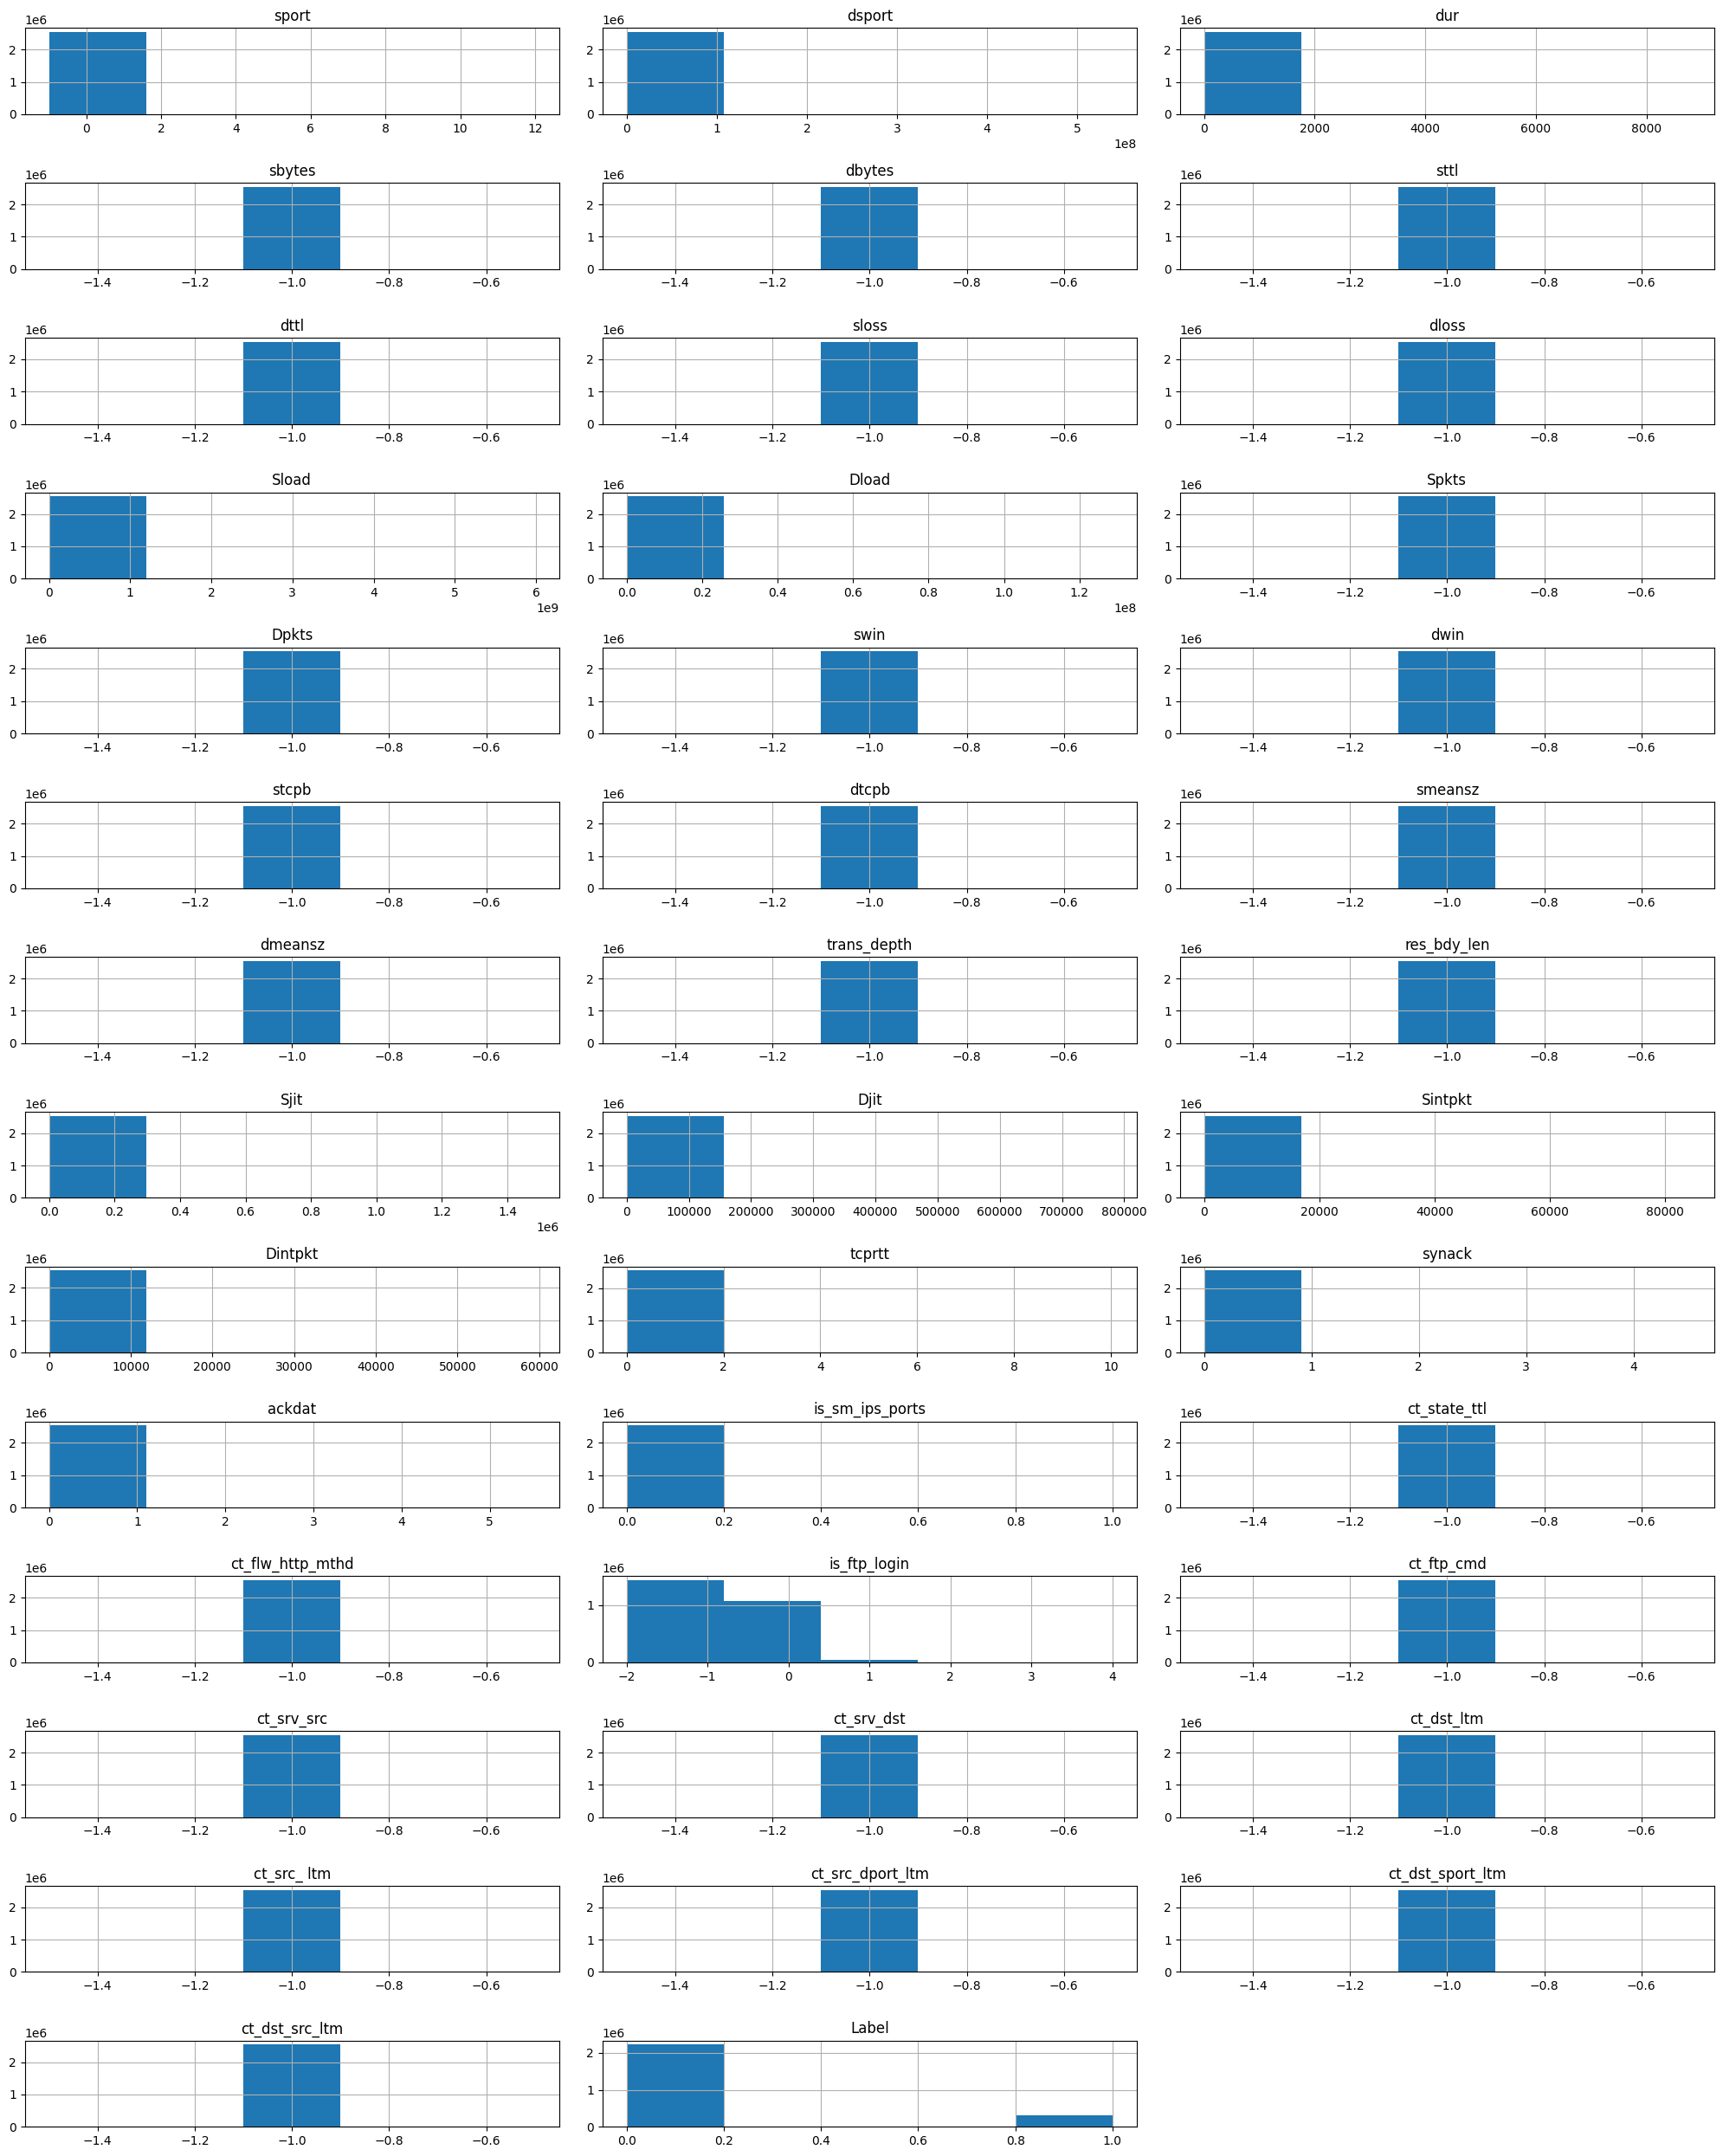

In [55]:
full_data.hist(bins=5, figsize=(20, 25), layout=(14, 3))  # 14 filas, 3 columnas
plt.tight_layout()
plt.show()